In [13]:
function dihotomic(f, a, b, eps, delta, max_iters)
  i = 0
  while i < max_iters && abs(b - a) > eps
    lambda = (a + b) / 2 - delta
    mu = (a + b) / 2 + delta
    if f(lambda) < f(mu)
      b = mu
    else
      a = lambda
    end
    i += 1
  end

  if abs(b - a) < eps
    return a, b, f((a + b) / 2)
  else
    error("Maximum iterations reached without convergence.")
  end
end

dihotomic (generic function with 1 method)

In [47]:
# Binary search for point where df/dx = 0
function dx_bs_min(f, a, b, eps)
  step = log2((b - a) / eps)
  res = a
  while step > 0
    df = f(res + step) - f(res + step - eps)
    if a + step <= b && df < 0
      res += step
    end
    step /= 2
  end
  return res, f(res)
end

dx_bs_min (generic function with 1 method)

In [80]:
using Plots
using Printf
using BenchmarkTools

function calculate_min(f, a, b)
  a_min, b_min, f_min = dihotomic(f, a, b, 1e-4, 1e-6, 1000000)
  bs_min, f_bs_min = dx_bs_min(f, a, b, 1e-8)

  @printf("Dihotomic method: ")
  @btime dihotomic($f, $a, $b, 1e-4, 1e-6, 1000000)
  @printf("Minimum found in the interval: [%.4f, %.4f]\n", a_min, b_min)
  @printf("With x ~= %.4f and f(x) min ~= %.4f\n", (a_min + b_min)/2, f_min)
  
  @printf("\nBinary search method: ")
  @btime dx_bs_min($f, $a, $b, 1e-8)
  @printf("x ~= %.4f and f(x) min ~= %.4f\n", bs_min, f_bs_min)

  # 4. Plot the function and mark the findings
  x = a:0.01:b
  y = f.(x)
  p = plot(x, y, label="f(x)", title="Function Plot", xlabel="x", ylabel="f(x)")
end

calculate_min (generic function with 1 method)

Dihotomic method:   100.250 ns (4 allocations: 80 bytes)
Minimum found in the interval: [-0.5001, -0.5000]
With x ~= -0.5000 and f(x) min ~= 0.7500

Binary search method:   3.217 μs (3 allocations: 64 bytes)
x ~= -0.5000 and f(x) min ~= 0.7500


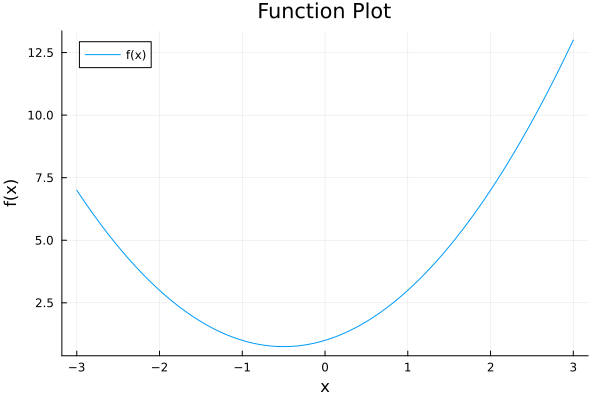

In [81]:
f(x) = x^2 + x + 1
calculate_min(f, -3, 3)

Dihotomic method:   204.381 ns (4 allocations: 80 bytes)
Minimum found in the interval: [-0.1028, -0.1027]
With x ~= -0.1028 and f(x) min ~= 1.9491

Binary search method:   11.732 μs (3 allocations: 64 bytes)
x ~= -0.1027 and f(x) min ~= 1.9491


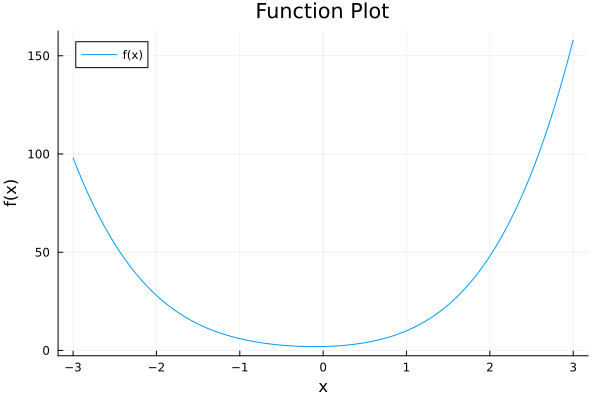

In [82]:
f(x) = x^4 + x^3 + 5x^2 + x + 2
calculate_min(f, -3, 3)

Dihotomic method:   104.091 ns (4 allocations: 80 bytes)
Minimum found in the interval: [-0.1000, -0.1000]
With x ~= -0.1000 and f(x) min ~= 15.9500

Binary search method:   3.224 μs (3 allocations: 64 bytes)
x ~= -0.1000 and f(x) min ~= 15.9500


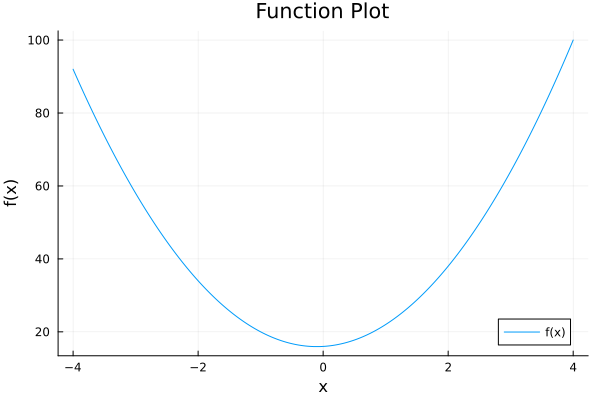

In [83]:
f(x) = 5x^2 + x + 16
calculate_min(f, -4, 4)

Dihotomic method:   305.168 ns (4 allocations: 80 bytes)
Minimum found in the interval: [-0.7854, -0.7853]
With x ~= -0.7854 and f(x) min ~= -1.4142

Binary search method:   22.812 μs (3 allocations: 64 bytes)
x ~= -0.7854 and f(x) min ~= -1.4142


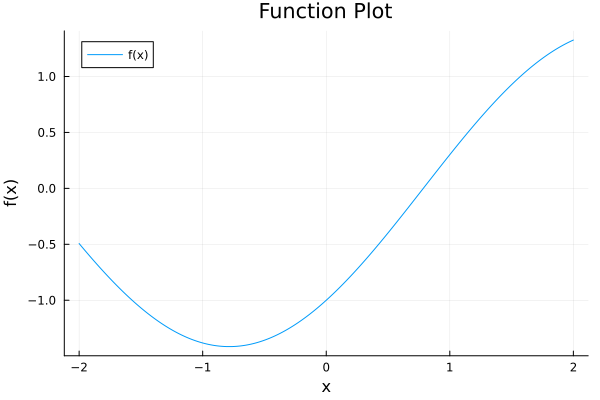

In [84]:
f(x) = sin(x) - cos(x)
calculate_min(f, -2, 2)

Dihotomic method:   452.873 ns (4 allocations: 80 bytes)
Minimum found in the interval: [-4.9113, -4.9112]
With x ~= -4.9112 and f(x) min ~= -5.0917

Binary search method:   28.002 μs (3 allocations: 64 bytes)
x ~= -4.9112 and f(x) min ~= -5.0917


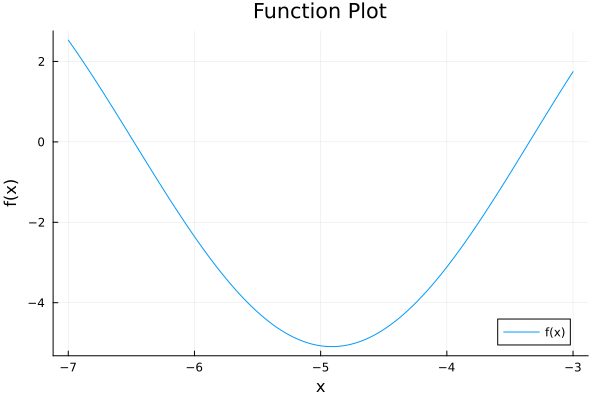

In [85]:
f(x) = exp(x) - cos(x) - 5sin(x)
calculate_min(f, -7, -3)

Dihotomic method:   200.644 ns (4 allocations: 80 bytes)
Minimum found in the interval: [0.3889, 0.3890]
With x ~= 0.3889 and f(x) min ~= -0.2086

Binary search method:   9.437 μs (3 allocations: 64 bytes)
x ~= 0.3889 and f(x) min ~= -0.2086


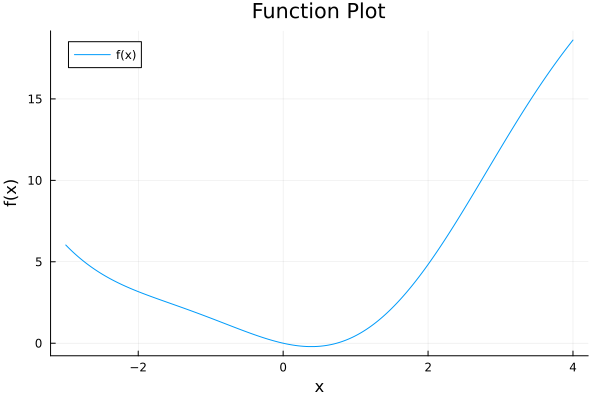

In [86]:
f(x) = x^2-x*cos(x)
calculate_min(f, -3, 4)